In [33]:
import glob
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# pandas の表示省略を無効化（必要なら値を調整）
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

units = [64, 128, 256]
base_path = "/work/robomimic/csv/result/error/proposal/gaussian"
TOP_K = 10  # 上位k行で平均

def extract_gaussian(path):
    m = re.search(r"gaussian([0-9.]+)\.csv", path)
    return float(m.group(1)) if m else None

results = []

for unit in units:
    pattern = f"{base_path}/unit{unit}/gaussian*.csv"
    files = sorted(glob.glob(pattern))

    for f in files:
        g = extract_gaussian(f)
        if g is None:
            continue

        df = pd.read_csv(f)

        # === ここが変更点 ===
        # 行そのものから success_rate 上位kを選択
        topk = df.nlargest(TOP_K, "success_rate")
        mean_success = topk["success_rate"].mean()
        std_success = topk["success_rate"].std()

        results.append({
            "unit": unit,
            "gaussian": g,
            "mean_success": mean_success,
            "std_success": std_success
        })

results_df = pd.DataFrame(results)
display(results_df)


,unit,gaussian,mean_success,std_success
0,64,0.00,0.963,0.014181
1,64,0.01,0.977,0.014944
2,64,0.02,0.957,0.017029
3,64,0.03,0.893,0.045959
4,64,0.04,0.796,0.083825
5,64,0.05,0.694,0.118340
6,64,0.06,0.509,0.194276
7,64,0.07,0.526,0.241854
8,64,0.08,0.420,0.222810
9,64,0.09,0.279,0.209839


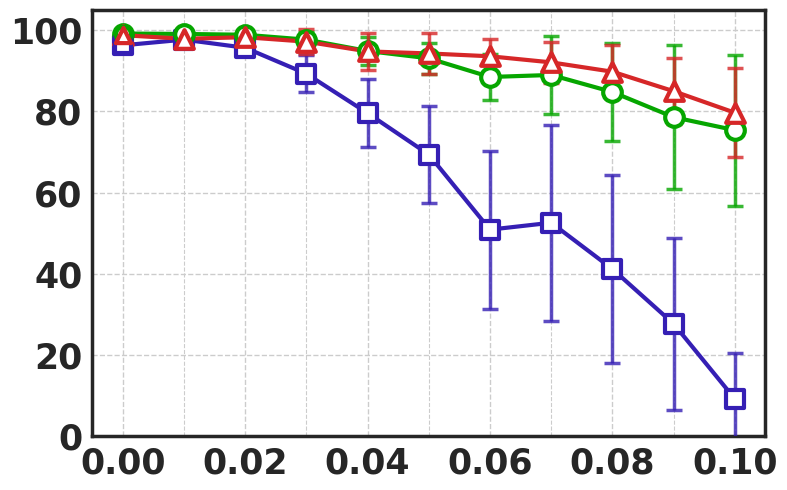

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
custom_colors = { "ncp_u64_best": "#351fb4", "u64": "#351fb4", "ncp_u128_best": "#06a600", "u128": "#06a600", "ncp_u256_best": "#d62728", "u256": "#d62728", } 
markers = { "ncp_u64_best": "s", "u64": "s", "ncp_u128_best": "o", "u128": "o", "ncp_u256_best": "^", "u256": "^", }
sns.set_style("white")

# ===== フォントサイズ設定 =====
TICK_SIZE = 25
LABEL_SIZE = 28
LEGEND_SIZE = 22

plt.figure(figsize=(8, 5))

for unit, color, marker in zip(
    units,
    [custom_colors["u64"], custom_colors["u128"], custom_colors["u256"]],
    [markers["u64"], markers["u128"], markers["u256"]],
):
    # results_df から直接取得
    df_u = results_df[results_df["unit"] == unit].sort_values("gaussian")

    # gaussian = 0.0 を強調
    if 0.0 in df_u["gaussian"].values:
        y0 = df_u.loc[df_u["gaussian"] == 0.0, "mean_success"].values[0]
        plt.scatter(
            [0.0], [y0 * 100],
            marker=marker,
            s=120,
            facecolors="white",
            edgecolors=color,
            linewidths=3,
            zorder=6,
        )

    # 折れ線
    plt.plot(
        df_u["gaussian"],
        df_u["mean_success"] * 100,
        color=color,
        linewidth=3,
        zorder=3,
        label=f"u{unit}",
    )

    # マーカー
    plt.scatter(
        df_u["gaussian"],
        df_u["mean_success"] * 100,
        marker=marker,
        s=180,
        facecolors="white",
        edgecolors=color,
        linewidths=3,
        zorder=5,
    )

    # ===== エラーバー =====
    plt.errorbar(
        df_u["gaussian"],
        df_u["mean_success"] * 100,
        yerr=df_u["std_success"] * 100,
        fmt="none",          # マーカーは描かない
        ecolor=color,
        elinewidth=2.5,
        capsize=6,
        capthick=2.5,
        zorder=3,
        alpha=0.8,
    )

# ===== 軸設定 =====
plt.ylim(0, 105)
plt.xlim(-0.005, 0.105)

plt.xticks(
    np.arange(0.0, 0.11, 0.02),
    fontsize=TICK_SIZE,
    fontweight="bold",
)
plt.yticks(
    np.arange(0, 101, 20),
    fontsize=TICK_SIZE,
    fontweight="bold",
)

# ===== グリッド =====
ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.02))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.01))

ax.grid(which="major", linestyle="--", linewidth=1.0)
ax.grid(which="minor", linestyle="--", linewidth=0.8)

# ===== 枠線 =====
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

plt.tight_layout()
plt.show()


In [34]:
import glob
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

units = [64, 128, 256]
base_path = "/work/robomimic/csv/result/error/proposal/shift"
TOP_K = 10  # 上位k行で平均

def extract_shift(path):
    m = re.search(r"shift([0-9.]+)\.csv", path)
    return float(m.group(1)) if m else None

results = []

for unit in units:
    pattern = f"{base_path}/u{unit}/shift*.csv"
    files = sorted(glob.glob(pattern))

    for f in files:
        s = extract_shift(f)
        if s is None:
            continue

        df = pd.read_csv(f)

        # === ここが変更点 ===
        # 行そのものから success_rate 上位kを選択
        topk = df.nlargest(TOP_K, "success_rate")
        mean_success = topk["success_rate"].mean()
        std_success = topk["success_rate"].std()

        results.append({
            "unit": unit,
            "shift": s,
            "mean_success": mean_success,
            "std_success": std_success
        })

results_df_shift = pd.DataFrame(results)
display(results_df_shift)

,unit,shift,mean_success,std_success
0,64,0.00,0.963,0.014181
1,64,0.01,0.969,0.020248
2,64,0.02,0.949,0.026437
3,64,0.03,0.942,0.026162
4,64,0.04,0.921,0.045326
5,64,0.05,0.893,0.050343
6,64,0.06,0.868,0.063034
7,64,0.07,0.854,0.082624
8,64,0.08,0.835,0.080588
9,64,0.09,0.800,0.085245


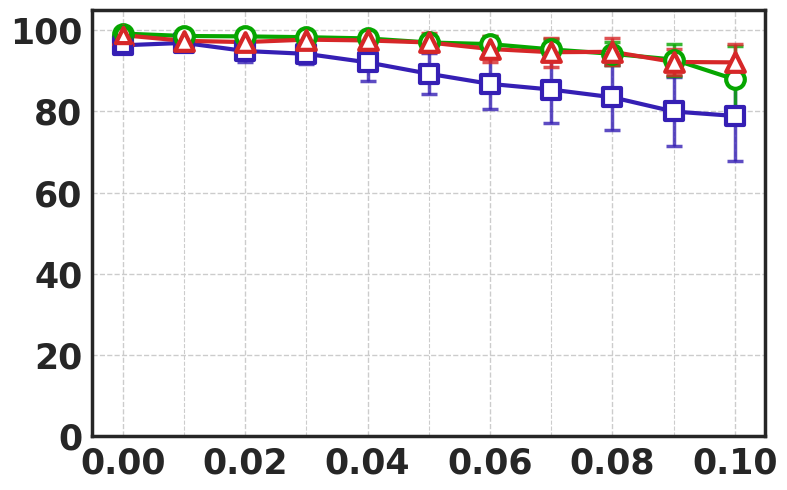

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
custom_colors = { "ncp_u64_best": "#351fb4", "u64": "#351fb4", "ncp_u128_best": "#06a600", "u128": "#06a600", "ncp_u256_best": "#d62728", "u256": "#d62728", } 
markers = { "ncp_u64_best": "s", "u64": "s", "ncp_u128_best": "o", "u128": "o", "ncp_u256_best": "^", "u256": "^", }
sns.set_style("white")

# ===== フォントサイズ設定 =====
TICK_SIZE = 25
LABEL_SIZE = 28
LEGEND_SIZE = 22

plt.figure(figsize=(8, 5))

for unit, color, marker in zip(
    units,
    [custom_colors["u64"], custom_colors["u128"], custom_colors["u256"]],
    [markers["u64"], markers["u128"], markers["u256"]],
):
    # results_df から直接取得
    df_u = results_df_shift[results_df_shift["unit"] == unit].sort_values("shift")

    # gaussian = 0.0 を強調
    if 0.0 in df_u["shift"].values:
        y0 = df_u.loc[df_u["shift"] == 0.0, "mean_success"].values[0]
        plt.scatter(
            [0.0], [y0 * 100],
            marker=marker,
            s=120,
            facecolors="white",
            edgecolors=color,
            linewidths=3,
            zorder=6,
        )

    # 折れ線
    plt.plot(
        df_u["shift"],
        df_u["mean_success"] * 100,
        color=color,
        linewidth=3,
        zorder=3,
        label=f"u{unit}",
    )

    # マーカー
    plt.scatter(
        df_u["shift"],
        df_u["mean_success"] * 100,
        marker=marker,
        s=180,
        facecolors="white",
        edgecolors=color,
        linewidths=3,
        zorder=5,
    )

    # ===== エラーバー =====
    plt.errorbar(
        df_u["shift"],
        df_u["mean_success"] * 100,
        yerr=df_u["std_success"] * 100,
        fmt="none",          # マーカーは描かない
        ecolor=color,
        elinewidth=2.5,
        capsize=6,
        capthick=2.5,
        zorder=3,
        alpha=0.8
    )

# ===== 軸設定 =====
plt.ylim(0, 105)
plt.xlim(-0.005, 0.105)

plt.xticks(
    np.arange(0.0, 0.11, 0.02),
    fontsize=TICK_SIZE,
    fontweight="bold",
)
plt.yticks(
    np.arange(0, 101, 20),
    fontsize=TICK_SIZE,
    fontweight="bold",
)

# ===== グリッド =====
ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.02))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.01))

ax.grid(which="major", linestyle="--", linewidth=1.0)
ax.grid(which="minor", linestyle="--", linewidth=0.8)

# ===== 枠線 =====
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

plt.tight_layout()
plt.show()
